In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/notebooks/sysiphusyxj/iris-model'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/sysiphusyxj/iris-model/__results__.html
/kaggle/input/notebooks/sysiphusyxj/iris-model/__resultx__.html
/kaggle/input/notebooks/sysiphusyxj/iris-model/__notebook__.ipynb
/kaggle/input/notebooks/sysiphusyxj/iris-model/__output__.json
/kaggle/input/notebooks/sysiphusyxj/iris-model/custom.css



Information Gain
x = 0.0
y = 1.0
z = 0.0

Actual Class
['I', 'I', 'II', 'II']

Predicted Class
['I', 'I', 'II', 'II']
Tree Depth = 1


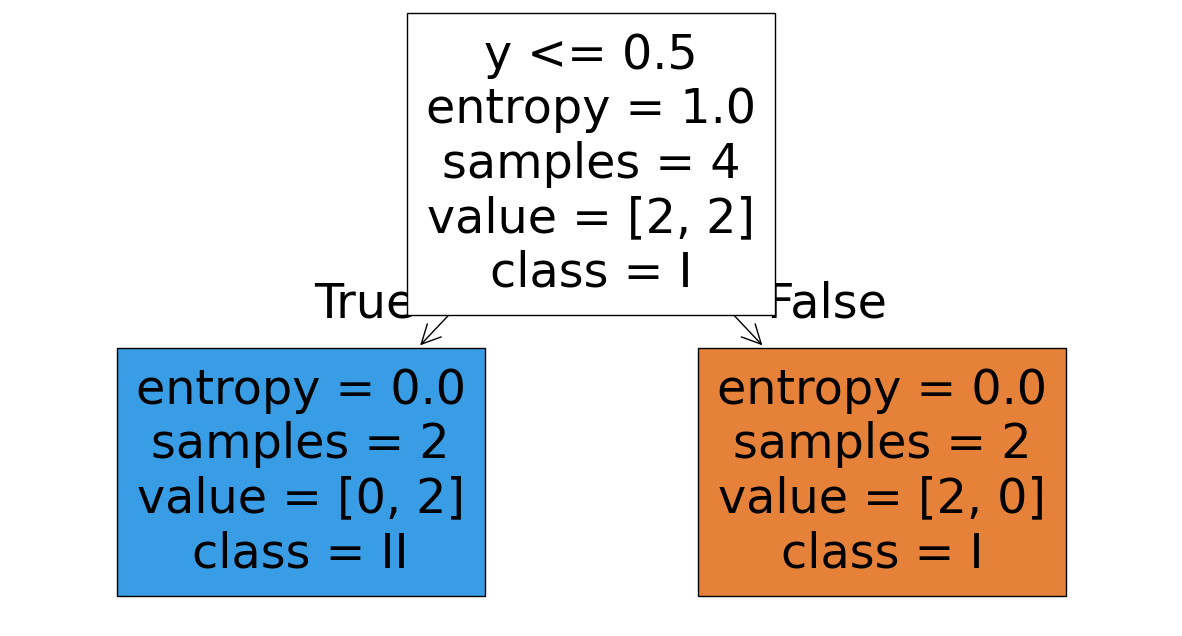

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

data = {
    'x': [1, 1, 0, 1],
    'y': [1, 1, 0, 0],
    'z': [1, 0, 1, 0],
    'class': ['I', 'I', 'II', 'II']
}

df = pd.DataFrame(data)

X = df[['x', 'y', 'z']]
y = df['class']

model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X, y)

print("\nInformation Gain")

for feature, importance in zip(X.columns, model.feature_importances_):
    print(feature, "=", round(importance, 4))

y_pred = model.predict(X)

print("\nActual Class")
print(list(y))

print("\nPredicted Class")
print(list(y_pred))

print("Tree Depth =", model.get_depth())

plt.figure(figsize=(15,8))
plot_tree(model, feature_names=X.columns, class_names=model.classes_, filled=True)
plt.show()

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  

Information Gain
sepal length (cm) = 0.0116
sepal width (cm) = 0.0
petal length (cm) = 0.657
petal width (cm) = 0.3314


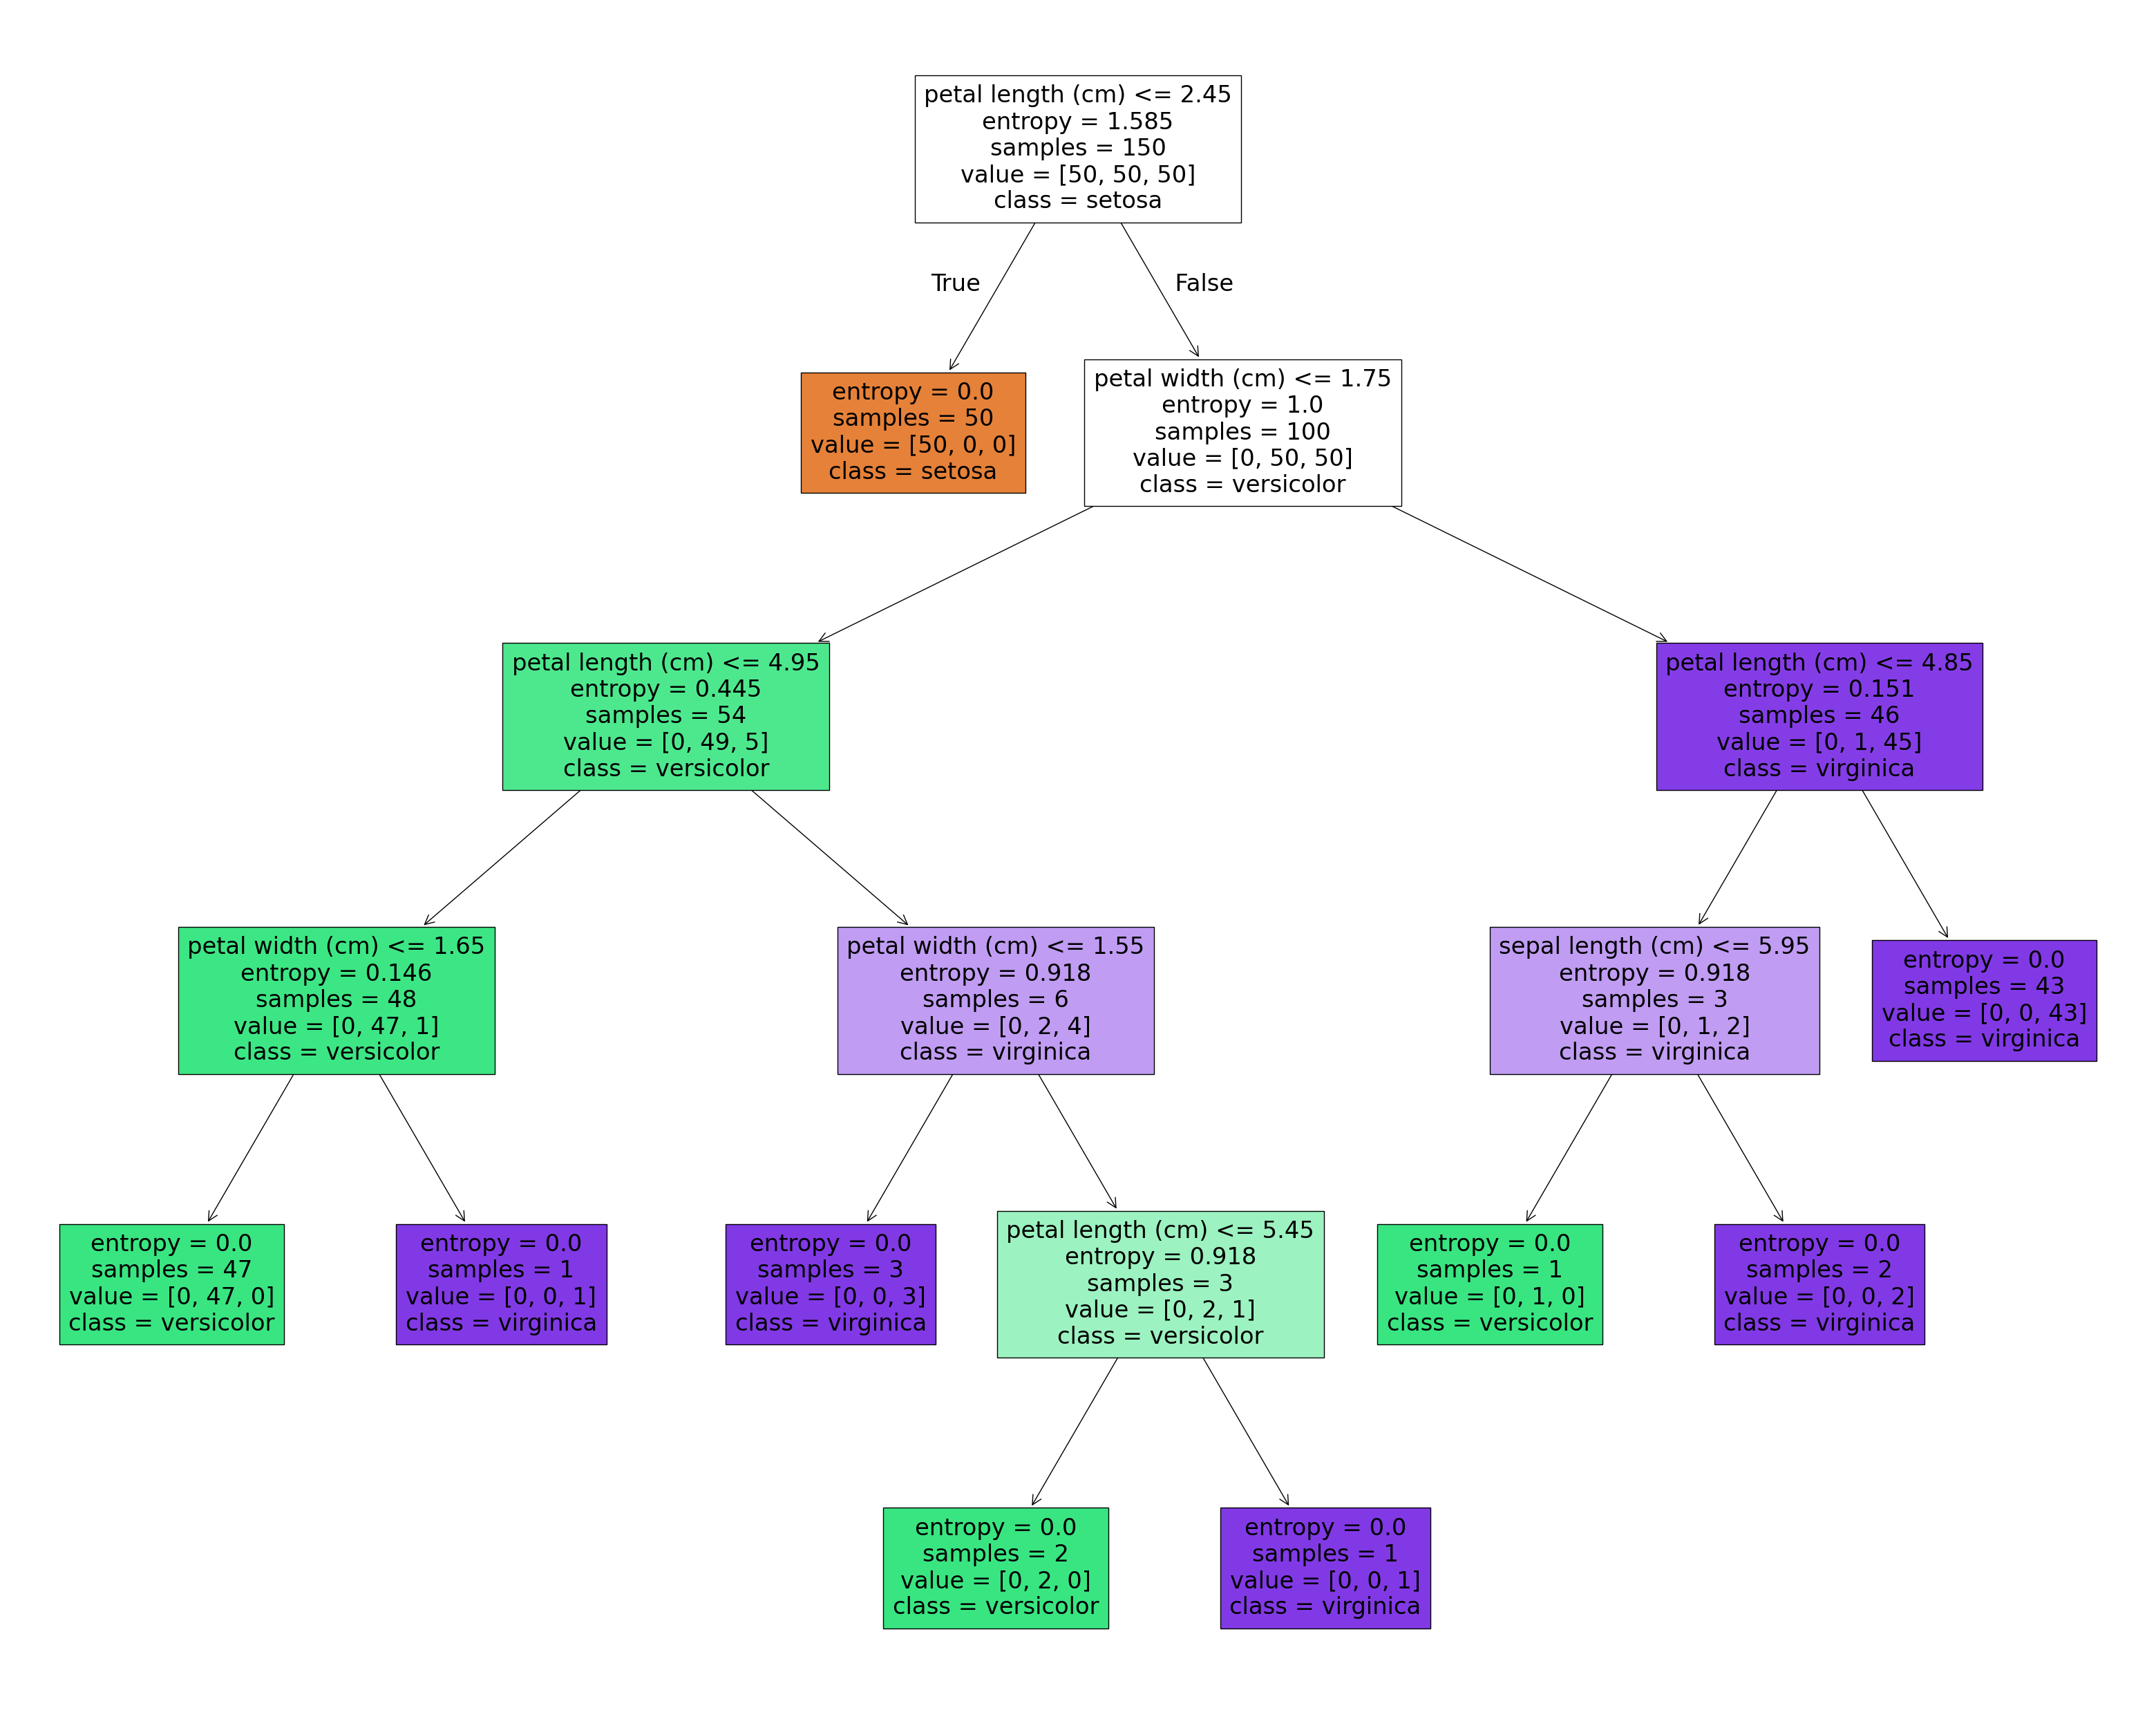

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Load Iris dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add target
df['species'] = iris.target

print(df.head())

# Features and target
X = df.drop('species', axis=1)
y = df['species']

# Create Decision Tree
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=1,
    random_state=42
)

# Train model
model.fit(X, y)

# Predict
y_pred = model.predict(X)

print("\nActual Class")
print(list(y))

print("\nPredicted Class")
print(list(y_pred))

# Display Decision Tree
plt.figure(figsize=(10, 8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=iris.target_names,
    filled=True
)

plt.show()

IRIS DATASET
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm Species
0            5.1           3.5            1.4           0.2  setosa
1            4.9           3.0            1.4           0.2  setosa
2            4.7           3.2            1.3           0.2  setosa
3            4.6           3.1            1.5           0.2  setosa
4            5.0           3.6            1.4           0.2  setosa

Dataset Shape:
(150, 5)

Column Names:
Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null   

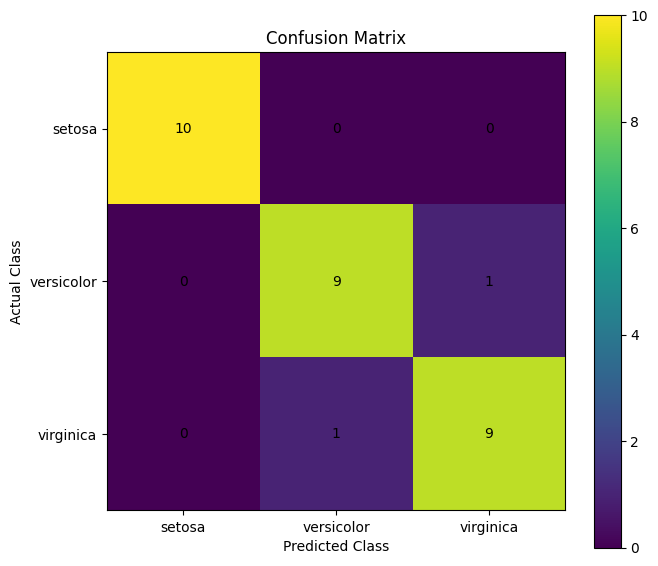

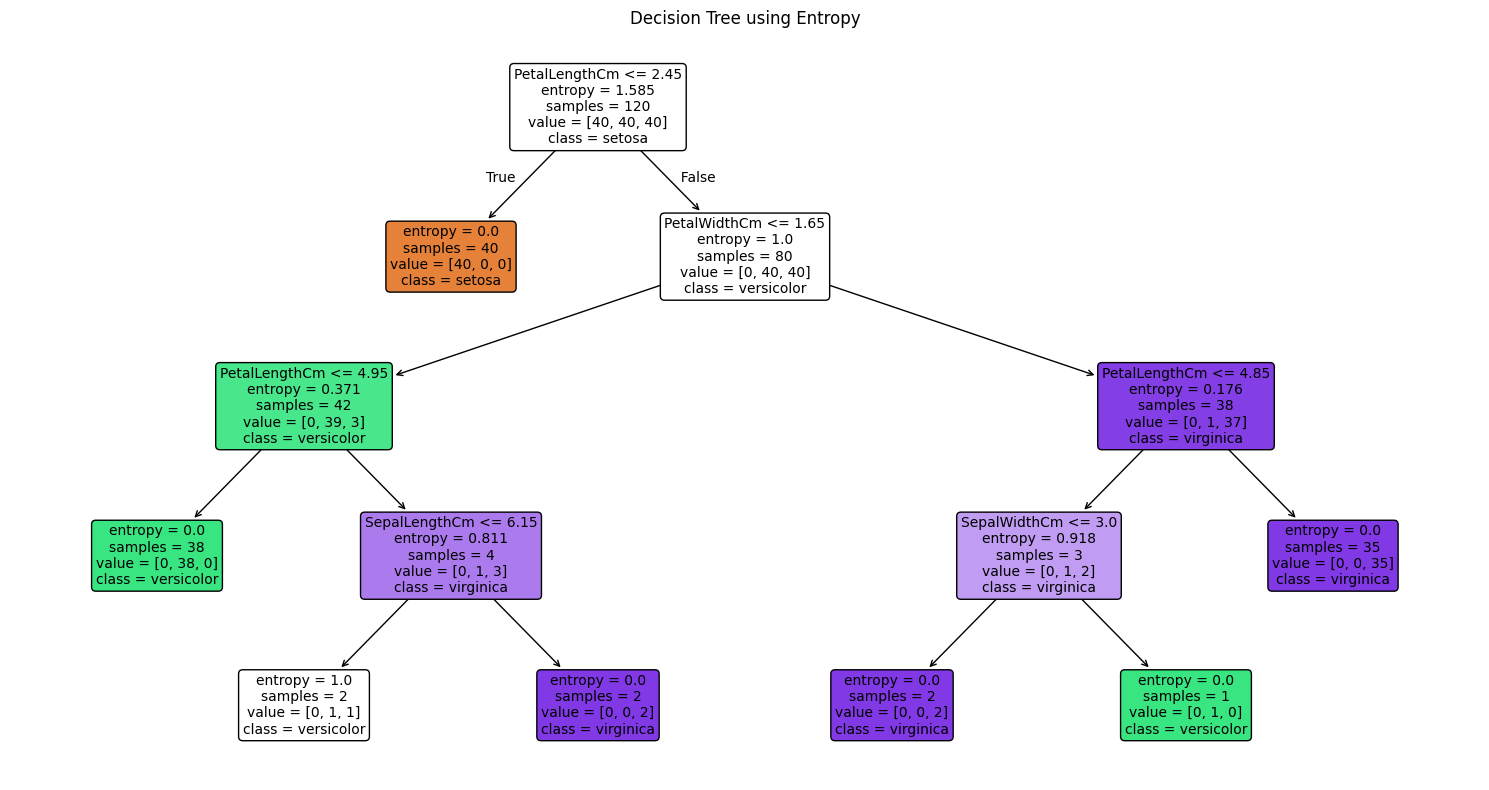

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Iris dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=[
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
)

# Convert target numbers to class names
df["Species"] = [iris.target_names[i] for i in iris.target]

print("=" * 60)
print("IRIS DATASET")
print("=" * 60)

print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nStatistical Description:")
print(df.describe())

print("\nClass Distribution:")
print(df["Species"].value_counts())


# Features
X = df[
    [
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
]

y = df["Species"]



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])



model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)


model.fit(X_train, y_train)

print("\nDecision Tree Training Completed")



y_pred = model.predict(X_test)

print("\nActual values:")
print(y_test.values)

print("\nPredicted values:")
print(y_pred)



accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 60)
print("MODEL ACCURACY")
print("=" * 60)

print("Accuracy =", round(accuracy * 100, 2), "%")



print("\nClassification Report:")
print(classification_report(y_test, y_pred))



cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)



plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    range(len(model.classes_)),
    model.classes_
)

plt.yticks(
    range(len(model.classes_)),
    model.classes_
)

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()



plt.figure(figsize=(15, 8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree using Entropy")
plt.tight_layout()
plt.show()